In [1]:
import os.path
from scipy import *
import numpy as np
from numpy import *
from numpy import linalg as LA
from scipy import linalg as LA2
import sympy as sympy
import sys as sys
import time
import matplotlib as mpl
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import itertools as it
from mpl_toolkits.mplot3d import Axes3D
from IPython.core.display import HTML


sys.path.append('/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/')
from Modules import BasicTools as BT
from Modules import WaveTools as WT
from Modules import PlotTools as PT
from Modules import FFTTools as FFTT
from Modules import OperatorTools as OT
from Modules import GridTransferTools as GTT
from Modules import TestTools as TT
from Modules import SolverTools as ST
from Modules import WaveformTools as WFT

display(HTML("<style>pre { white-space: pre !important; }</style>"))
np.set_printoptions( linewidth = 10000, threshold = 100000)

In [2]:
nh_min = 4
refRatio = 2

In [3]:
def TickPlot(omega, ax, tickHeight, xGrid, yGrid, label = False, u = [], labelsize = 10, linewidth = 1.5, matVis = False, fill = False, var = var, ghost = '', something = True, ShiftX = 0, ShiftY = 0):
    fontsize = 11

    if (yGrid):
        ax.grid(True, axis = 'y', zorder = 0)
    if (xGrid):
        ax.grid(True, axis = 'x', zorder = 0)
    xAxis = omega.xNode + ShiftX
    yAxis = omega.y + ShiftY

    xCell = omega.xCell
    nh = omega.nh_max
    # shiftX = 0.025
    # shiftY = tickHeight
    # extraShift = 0
    
    # if (matVis != ''):
    #     ind = r'h'
    # else:
    #     ind = r'j'
    # color = 2
    
    
    # if (u != []):
    #     level = ''
    #     if (ghost != ''):
    #         level = r'^{(l - 1)}'
    #         if (ghost == 'G1'):
    #             n = 6
    #         else:
    #             if (ghost == 'G2'):
    #                 n = 7
    #             else:
    #                 n = 5
            
    #     else:
    #         n = 4
    #     label = False
    #     xAxis = xAxis[1:n + 1]
    #     yAxis = yAxis[1:n + 1]
    #     shiftX = shiftX / 5
    # i = 0
    j = 0
    
    # LS = ':'
    
    # L1R1bot = 0
    # scootch = 0
    # side = ''

    # if ((matVis == 'R1') or (matVis == 'R2')):
    #     var = 'R'
    #     side = '1'
    #     if (matVis == 'R2'):
    #         side = '2'
    # else:
    #     if ((matVis == 'L1') or (matVis == 'L2')):
    #         var = 'L'
    #         side = '1'
    #         if (matVis == 'L2'):
    #             side = '2'
    
    for (xi, yi) in zip(xAxis, yAxis):
        j = j + 1
        if ((xi == 0) or (xi == 1)):
            height = tickHeight
            shiftY = tickHeight
            # if (label):
            #     plt.text(xi - shiftX, yi + shiftY, int(xi), fontsize = fontsize)
        else:
            height = tickHeight / 2
        if (((j != 1) or (matVis != 'L2')) and ((j != 4) or (matVis != 'R1'))):
            (xs, ys) = PT.DrawLine(xi, yi, height)
            ax.plot(xs, ys, color = 'k', zorder = 2, linewidth = linewidth)
            
        # if (label):
        #     if ((i < 3) or (i > nh - 2)):
        #         prestring = r'$j = $'
        #         istring = prestring + str(i)
        #         shiftExtra = 2 * shiftX
        #         if (i == nh - 1):
        #             istring = prestring + r'$n - 1$'
        #             shiftExtra = 4 * shiftX
        #         if (i == nh):
        #             istring = prestring + r'$n$'
        #             shiftExtra = shiftX
        #         plt.text(xi - shiftX - shiftExtra, yi - (1.5 * shiftY), istring, fontsize = fontsize)
#         if (u != []):
#             if (i == 0):
#                 color = 2
#                 topString = r'$' + var + r'_{' + side + ind + r' - 1}$'
#                 if (matVis == 'L2'):
#                     botString = ''
#                     topString = ''
#                 else:
#                     if ((matVis == 'R1') or (matVis == 'L1') or (ghost != '')):
#                         L1R1bot = -0.001
#                         botString = r'$x_{' + ind + r' - 2}' + level + r'$'
#                         topString = r'$' + var + r'_{' + side + ind + r' - 2}$'
#                     else:
#                         botString = r'$x_{' + ind + r' - 1}$'
#                         if (matVis == 'R2'):
#                             topString = r'$' + var + r'^{*}_{' + side + ind + r' - 1}$'
#                 if (fill or (matVis != '')):
#                     if (matVis == 'L2'):
#                         midString = ''
#                     else:
#                         if ((matVis == 'R1') or (matVis == 'L1')):
#                             extraShift = 0.002
#                             midString = r'$\Delta x_{' + ind + r' - 2}$'
#                         else:
#                             midString = r'$\Delta x_{' + ind + r' - 1}$'
#                 else:
#                     midString = r'$\left<x\right>_{' + ind + r' - 1}$'
#             else:
#                 if (i == 1):
                    
#                     if ((matVis == 'R2') or (matVis == 'L2')):
#                         LS = '-'
#                     shiftX = shiftX / 2
#                     extraShift = 0.002
#                     topString = r'$' + var + r'_{' + side + ind + r'}$'
#                     if ((matVis == 'R1') or (matVis == 'L1') or (ghost != '')):
#                         extraShift = extraShift + 0.001
#                         L1R1bot = -0.002
#                         if (ghost != ''):
#                             L1R1bot = -0.005
#                         if (ghost == 'G2'):
#                             level = r'^{(l)}'
#                             botString = r'$x_{2' + ind + r' - 2}' + level + r'$'
#                         else:
#                             botString = r'$x_{' + ind + r' - 1}' + level + r'$'
#                     else:
#                         botString = r'$x_{' + ind + r'}$'
                
#                     if (fill or (matVis != '')):
#                         if ((matVis == 'R1') or (matVis == 'L1')):
#                             midString = r'$\Delta x_{' + ind + r' - 1}$'
#                             topString = r'$' + var + r'_{' + side + ind + r' - 1}$'
#                         else:
#                             midString = r'$\Delta x_{' + ind + r'}$'
#                     else:
#                         midString = r'$\left<x\right>_{' + ind + r'}$'
#                 else:
# #                     color = 2
#                     shiftX = 2 * shiftX
#                     extraShift = 0
#                     topString = r'$' + var + r'_{' + side + ind + r' + 1}$'
#                     if (i == 2):
#                         if ((matVis == 'R1') or (matVis == 'L1')):# or (ghost == 'G1')):
#                             LS = '-'
#                             L1R1bot = 0.002
#                             botString = r'$x_{' + ind + r'}$'
#                         else:
#                             botString = r'$x_{' + ind + r' + 1}$'
                        
#                         if (ghost != ''):
#                             if (ghost == 'G2'):
#                                 botString = r'$x_{2' + ind + r' - 1}' + level + r'$'
#                             else:
#                                 LS = '-.'
#                                 if (ghost == 'G1'):
#                                     L1R1bot = 0.002
#                                     level = r'^{(l)}'
#                                     botString = r'$x_{2' + ind + r'}' + level + r'$'
                                    
#                                 else:
#                                     botString = r'$x_{' + ind + r'}' + level + r'$'
                        
                        
#                         if (fill or (matVis != '')):
#                             if (matVis == 'R1'):
#                                 midString = ''
#                                 topString = r'$' + var + r'_{' + side + ind + r'}$'
#                             else:
#                                 if (matVis == 'L1'):
#                                     midString = r'$\Delta x_{' + ind + r'}$'
#                                     topString = r'$' + var + r'_{' + side + ind + r'}$'
#                                 else:
#                                     midString = r'$\Delta x_{' + ind + r' + 1}$'
#                         else:
#                             midString = r'$\left<x\right>_{' + ind + r' + 1}$'
                            
#                     if (i == 3):
#                         shiftX = shiftX / 5
#                         scootch = -0.002
#                         topString = r'$' + var + r'_{' + side + ind + r' + 2}$'
#                         if (matVis == 'R1'):
#                             L1R1bot = -0.003
#                             botString = ''
#                             topString = ''
#                         else:
#                             if (matVis == 'L1'):
#                                 L1R1bot = -0.003
#                                 botString = r'$x_{' + ind + r' + 1}$'
#                                 topString = r'$' + var + r'^{*}_{' + side + ind + r' + 1}$'
#                             else:
#                                 L1R1bot = 0#-0.001
#                                 botString = r'$x_{' + ind + r' + 2}$'
#                         if (ghost != ''):
#                             level = r'^{(l)}'
#                             if (ghost == 'G1'):
#                                 L1R1bot = -0.003
#                                 botString = r'$x_{2' + ind + r' + 1}' + level + r'$'
#                             else:
#                                 L1R1bot = -0.001
#                                 if (ghost == 'G2'):
#                                     botString = r'$x_{2' + ind + r'}' + level + r'$'
#                                     LS = '-.'
#                                 else:
#                                     botString = r'$x_{2' + ind + r' + 2}' + level + r'$'

#                         midString = ''
#                     if (i == 4):
#                         L1R1bot = -0.001
#                         if (ghost == 'G1'):
#                             botString = r'$x_{2' + ind + r' + 2}' + level + r'$'
#                         else:
#                             if (ghost == 'G2'):
#                                 botString = r'$x_{2' + ind + r' + 1}' + level + r'$'
#                             else:
#                                 botString = r'$x_{2' + ind + r' + 3}' + level + r'$'
#                     if (i == 5):
#                         L1R1bot = 0.003
#                         if (ghost == 'G1'):
#                             botString = r'$x_{2' + ind + r' + 3}' + level + r'$'
#                         else:
#                             botString = r'$x_{2' + ind + r' + 2}' + level + r'$'
#                     if (i == 6):
#                         L1R1bot = 0.011
#                         botString = r'$x_{2' + ind + r' + 3}' + level + r'$'
        #     if (not fill):
        #         if (((i != 0) or (matVis != 'L2')) and ((i != 3) or (matVis != 'R1')) and something):
        #             (xs, ys) = DrawLine(xi, yi, u[i + 1], center = False)
        #             ax.plot(xs, ys, color = ColorDefault(color), zorder = 1, linestyle = LS)
        #         LS = ':'
        #         if ((ghost == '') and something):
        #             plt.text(xi - shiftX + scootch, u[i + 1] + (shiftY / 3), topString, fontsize = fontsize, zorder = 6)
        #         print(i, xi - shiftX + L1R1bot, botString)
        #         plt.text(xi - shiftX + L1R1bot, yi - 0.8 * shiftY, botString, fontsize = fontsize)
        #         L1R1bot = 0
        #     if ((i < 3) and (ghost == '')):
        #         plt.text(xCell[i + 1] - shiftX - extraShift, yi - 0.8 * shiftY, midString, fontsize = fontsize)
        # i = i + 1
    # if (u == []):
    ax.plot(xAxis, yAxis, color = 'k', zorder = 2, linewidth = linewidth)
    plt.tick_params(reset = True, axis = 'x', which = 'both', bottom = False, top = False, labelbottom = xGrid, labelsize = labelsize)
    plt.tick_params(reset = True, axis = 'y', which = 'both', left = False, right = False, labelleft = yGrid, labelsize = labelsize)
    ax.spines[['top', 'bottom', 'left', 'right']].set_visible(False) # THIS WAS ADDED AFTER PYTHON UPDATE!!!
    if (xGrid): # THIS WAS ADDED AFTER PYTHON UPDATE!!!
        ax.grid(visible = xGrid, zorder = -1, axis = 'x') # THIS WAS ADDED AFTER PYTHON UPDATE!!!
    if (yGrid): # THIS WAS ADDED AFTER PYTHON UPDATE!!!
        ax.grid(visible = yGrid, zorder = -1, axis = 'y') # THIS WAS ADDED AFTER PYTHON UPDATE!!!
    return



In [4]:
def GridMap(nh_min, rescale = 1, save = False, saveName = '', dpi = 600, enlarge = False, label = False):
    numPoints, font, X, savePath = PT.UsefulPlotVals()
    if (saveName != ''):
        save = True
    else:
        saveName = 'Grid'
    
    if (enlarge):
        linewidth = 4
        fontsize = 35
        labelsize = 25
    else:
        linewidth = 1.5
        fontsize = 25
        labelsize = 10
    
    saveString = savePath + saveName
    yMin, yMax, tickHeight = PT.GetYBound(0, True)
    size, tickHeight, labelfont = PT.Resize(rescale, tickHeight)
    fig, ax = plt.subplots(figsize = size)
    omegaAMR = BT.Grid(nh_min)
    for i in range(1):
        shiftX = (1.5 * i) - 2
        print('iter:', i)
        nh = (2**i) * nh_min
        omegaF = BT.Grid(nh)
        cells = list(np.arange(2) + int(nh/2) - 1)
        print(cells)
        omegaAMR.AddPatch(refRatio, cells)
        if (i == 0):
            shiftY = 0
        else:
            shiftY = 0.5
            if (i != 2):
                TickPlot(omegaAMR, ax, tickHeight, False, False, label = label, labelsize = labelsize, linewidth = linewidth, ShiftX = shiftX, ShiftY = -shiftY)
        TickPlot(omegaF, ax, tickHeight, False, False, label = label, labelsize = labelsize, linewidth = linewidth, ShiftX = shiftX, ShiftY = shiftY)
    plt.ylim([yMin, yMax])
    plt.show()
    if (save):
        Save(fig, saveString, dpi)
    return

iter: 0
[1, 2]


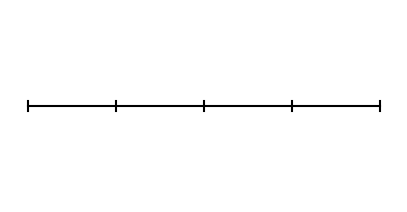

In [5]:
GridMap(nh_min)